# Resource Builder Notebook

In [ ]:
import warnings

from pathlib import Path
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import RES.RESources as RES_module

from RES import utility as utils
from RES.hdf5_handler import DataHandler

import RES.visual_styles as styles
style_path = Path(styles.__file__).parent / "elsevier.mplstyle"
plt.style.use(style_path)
# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)
cfg=utils.load_config('config/config_CAN.yaml')


## Set Required Args to Initialize Objects

- All steps are integrated in this 'RES_module.build()' method.

In [ ]:
# import RES.RESources as RES

# # Iterate over provinces for both solar and wind resources
# resource_types = ['wind','solar']  # 'solar'
# provinces=['BC']  #,'AB','SK','ON','NS','MB'
# for province_code in provinces:
#     for resource_type in resource_types:
#         required_args = {
#             "config_file_path": 'config/config_CAN.yaml',
#             "region_short_code": province_code,
#             "resource_type": resource_type
#         }
        
#         # Create an instance of Resources and execute the module
#         RES_module = RES.RESources_builder(**required_args)
        
    
#     # For complete workflow, uncomment the following line
#         # RES_module.build(select_top_sites=True,
#         #                  use_pypsa_buses=False)  


----

In [ ]:
# Construct region_options as a list of tuples: (name, code)
region_options = [(cfg['region_mapping'][code]['name'], code) for code in cfg['region_mapping']]
region_code = 'BC'  # Default selection, change as needed

# Create dropdown widget for region codes with names shown, codes as values
region_code_dropdown = widgets.Dropdown(
    options=region_options,
    value=region_code,
    description='Region:',
    disabled=False,
)

display(region_code_dropdown)

In [ ]:
resource_type_dropdown = widgets.Dropdown(
    options=['wind', 'solar'],
    value='wind',
    description='Resource:',)
display(resource_type_dropdown)


In [ ]:
resource_type = resource_type_dropdown.value
province_code = region_code_dropdown.value



required_args = {
    "config_file_path": 'config/config_CAN.yaml',
    "region_short_code": province_code,
    "resource_type": resource_type
}


# Create an instance of Resources and execute the module
RES_module = RES_module.RESources_builder(**required_args)

# Stepwise Checks/Debugging [when required]

### Step 1: Prepare Spatial Grid Cells

- This method collects the sub-national administrative boundaries. 
- Using that boundary, we calculate the Minimum Bounding Rectangle (MBR). 
- We use that MBR as a cutout to source weather resources data from ERA5 via CDSAPI. The ERA5's cutout is then stored as a netcdf `.nc' file.
- We load that cutout as `atlite`'s `cutout` object.
- We then use `atlite`'s `cutout.grid` attribute to create our test beds for the analysis i.e. the grid cells (geodataframe)

In [ ]:
step1_results=RES_module.get_grid_cells()

step1_results.head(5) # See the first 5 rows of the grid cells data

### Step 2: Calculate Potential Capacity

- This method loads the cutout (atlite's cutout object), regional boundary (GeoDataFrame), loads the cost parameters and  also initiates a __composite excluder__
  - The ([`atlite`'s exclusion container](https://atlite.readthedocs.io/en/master/ref_api.html#atlite.Cutout.availabilitymatrix)) to merge all the spatial layers.
- the `cutout.availabilitymatrix` method calculates % of usable area within each grid cell after applying exclusion criteria (e.g., protected areas, water bodies) and returns an [`AvaliabilityMatrix`](https://atlite.readthedocs.io/en/master/ref_api.html#atlite.Cutout.availabilitymatrix)
- We apply technology landuse intensity (e.g., MW/km² for wind or solar) to translate this to potential capacity data.
- We get the maximum installable capacity for each grid cell based on available area, land use constraints, and technology-specific parameters.
  > - Current results gives a percentage of availability for each grid cell. It does not tell specifically which spatial area inside a grid cell is unavailable.
  > - The _potential capacity_ translation processing involves `area` calculation. The area calculation method is integrated to `RES.cell_processor.get_capacity()`. That method is sensitive to area calculation specific coordinate-system projection of the geodataframe. It is recommended to be cautious about choosing this crs.
  

In [ ]:
step2_results=RES_module.get_cell_capacity()

- The Landavailability Map size may need some adjustments to look nicer
  > the defatult setup is adjusted for BC map

In [ ]:
figure=RES_module.cell_processor.plot_ERAF5_grid_land_availability(region_boundary=RES_module.gadmBoundary.get_region_boundary(),
                                                            Availability_matrix=RES_module.cell_processor.Availability_matrix,
                                                            figsize=(8, 8),
                                                            legend_box_x_y=(1.1, 0.9))


In [ ]:
RES_module.cell_processor.Availability_matrix.plot(cmap='Greens')

### Step 3: Get CF and Windspeed from Higher Resolution Data

> - Currently configured for Wind Resources only. Wind resources (windspeed) are known to have significant variations across ERA5's ~30km resolution. We rescaled the windspeed with higher resolution windspeed from Global Wind Atlas (GWA). Then we calculate the ERA5 scaled windspeed from the mapped GWA cells. However, GWA does not provide hourly profiles. We source the profile from ERA5.

- returns NONE if result datafield ('windspeed_ERA5') is already there 

In [ ]:
gwa_cells=RES_module.gwa_cells.load_gwa_cells()

* Plot Windspeed for 100m resolution cells (not a mandatory step, for cross checking purposes)
  > That's a high resolution data, may take a while to plot. Make sure your machine's cache memory is enough to hold this data.

In [ ]:
# gwa_cells.plot('windspeed_gwa',cmap="Blues",legend=True)

#### GWA Scaled Wind Speed vs ERA5 Windspeed Comparison

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(gwa_cells['windspeed_gwa'], bins=50, kde=True, color='steelblue', edgecolor='white', stat='density', alpha=0.6,legend=True)
sns.rugplot(gwa_cells['windspeed_gwa'], color='grey', height=0.02)

plt.title('Windspeed Distribution (GWA\'s 100m Resolution)', fontsize=14)
plt.xlabel('Windspeed (m/s)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'vis/{province_code}/gwa_resolution_windspeed_distribution_{province_code}.jpg', dpi=300)
# plt.show()

In [ ]:
step3_results_A=RES_module.extract_weather_data()

In [ ]:
step3_results_B=RES_module.update_gwa_scaled_params() # testing, 2025 04 21

* A comparison of ERA5 actual (from reanalysis dataset) windspeed vs GWA windspeed downscaled to ERA5 resolution.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot KDEs
step3_results_B['windspeed_ERA5'].plot.kde(color='orangered', linewidth=2, label='ERA5 Windspeed KDE')
step3_results_B['windspeed_gwa'].plot.kde(color='navy', linewidth=2, label='GWA Windspeed KDE')

# Plot histograms
step3_results_B['windspeed_ERA5'].plot.hist(bins=30, color='orange', edgecolor='white', density=True, alpha=0.4, label='ERA5 Windspeed')
step3_results_B['windspeed_gwa'].plot.hist(bins=30, color='skyblue', edgecolor='white', density=True, alpha=0.4, label='GWA Windspeed')

plt.title('Distribution of GWA and ERA5 Windspeed', fontsize=14, weight='bold')
plt.xlabel('Windspeed (m/s)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(f'vis/{province_code}/ERA5_resolution_windspeed_distribution_ERA5vsGWA_{province_code}.png', dpi=300)
plt.show()

### Step 4: Get Timeseries

- We define technology attributes.
- We extract timeseries using weather resources data from ERA5's cutout.
  - The timeseries calculation method currently configured with [atlite.cutout.pv](https://atlite.readthedocs.io/en/master/ref_api.html#atlite.Cutout.pv) and [atlite.cutout.wind](https://atlite.readthedocs.io/en/master/ref_api.html#atlite.Cutout.wind) methods.

> __Attention__
  > - Configure the timezone conversion information carefully to ensure proper usage of the timeseries in downstream modelling. 
  > - ERA5 provides naive timezone index data. We use the timezone information from config file to enable the timezone shift of the timeseries.
  > - However, after conversion we removed the timezone awareness from the datetime index to harmonize with pypsa supported timeseries index.

In [ ]:
step4_results=RES_module.get_CF_timeseries()

### Step 5: Find Grid Proximity

This information is critical for downstream operational analysis with this resource options.

> - Currently configured for Transmission Lines and/or Grid Substations.
> - We do not know the specific project point of a resource. Hence, the resource to grid-node distance has been calculated from the centroid of each grid to the grid node. 
> - If you have a specific project point, you should recalculate this distance with your specific project point.


- Identifies and assigns grid nodes to each cell. 
- Calculates distance (in km) from each grid cell to the nearest grid node (e.g., transmission line, substation) to assess connectivity and feasibility for energy transport.
    
    > If your use case of the resource options are to be plugged in to a downstream operational model (e.g. PyPSA), use harmonized nodes to populate this data.
    > harmonized nodes i.e. same data that are intended to be used as _bus_ nodes at your operational model. 


In [ ]:
step5_results=RES_module.find_grid_nodes(use_pypsa_buses=False)  # use_pypsa_buses=False

### Step 6: Scoring Metric to Rank the Sites

- Scores each grid cell based on multiple criteria (e.g., resource quality, proximity to grid), supporting site selection.

In [ ]:
step6_results=RES_module.score_cells()

In [ ]:
# step6_results[step6_results['potential_capacity_wind']>0]

### Step 7: Clusterized Representation of the Sites

- Groups grid cells into clusters based on spatial or resource characteristics to enable aggregated analysis.
- Produces time series data for each cluster, summarizing the resource and capacity factor information at the cluster leve

In [ ]:
step7_results_Clusters=RES_module.get_clusters(
                                               wcss_tolerance=0.1,)
step7_results_ClusterTS=RES_module.get_cluster_timeseries()


In [ ]:
step7_results_Clusters[0].head(10).plot()

In [ ]:
step7_results_Clusters[0][step7_results_Clusters[0].index.str.contains("Peace")]

- Creates Units Dictionary

In [ ]:
utils_dict=RES_module.units.create_units_dictionary()

# [Exploratory]

### Explore the outputs from Store

In [ ]:
# Define the directory and search pattern
data_store_dir = Path("data/store/")
search_keyword = f"resources_{region_code}_"

# List files containing the search pattern
matching_files = [str(f) for f in data_store_dir.glob(f"*{search_keyword}*") if f.is_file()]

# Extract run IDs from matching_files
run_ids = [f.replace(str(data_store_dir) + '/', '').replace(search_keyword, '').replace(".h5", '') for f in matching_files]


RUN_ID="default"

# Create dropdown widget
run_id_dropdown = widgets.Dropdown(
    options=run_ids,
    value=RUN_ID,
    description='Run ID:',
    disabled=False,
)

display(run_id_dropdown)

In [53]:
RUN_ID= run_id_dropdown.value
store=f"data/store/resources_{region_code}_{RUN_ID}.h5"# f"../data/store/resources_{province_code}.h5" 
res_store=DataHandler(store,show_structure=True) # the DataHandler object could be initiated without the store definition as well.

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
[key] dissolved_indices
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"suppor

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"","stderr":"","mime":[]}
10{"stdout":"","stderr":"","mime":[]}


In [ ]:
cells=res_store.from_store('cells')
boundary=res_store.from_store('boundary')
solar_clusters=res_store.from_store('clusters/solar')
wind_clusters=res_store.from_store('clusters/wind')
solar_clusters_ts=res_store.from_store('timeseries/clusters/solar')
wind_clusters_ts=res_store.from_store('timeseries/clusters/wind')
dissolved_indices_solar=res_store.from_store('dissolved_indices/solar')
dissolved_indices_wind=res_store.from_store('dissolved_indices/wind')

- Interactive Map

In [ ]:
# wind_clusters[wind_clusters['lcoe']<=100].explore('potential_capacity')

# Playground for Top Site Selection

In [ ]:
resource_clusters_solar,cluster_timeseries_solar=RES_module.select_top_sites(solar_clusters,
                                                                solar_clusters_ts,
                                                                    resource_max_capacity=10)

resource_clusters_wind,cluster_timeseries_wind=RES_module.select_top_sites(wind_clusters,
                                                                wind_clusters_ts,
                                                                    resource_max_capacity=50)

In [ ]:
dissolved_indices_wind

In [ ]:
RES_module.export_results('wind',
                          province_code,
                    resource_clusters_wind,
                    cluster_timeseries_wind,)

In [ ]:
RES_module.export_results('solar',
                             province_code,
                    resource_clusters_solar,
                    cluster_timeseries_solar,)

<Axes: >

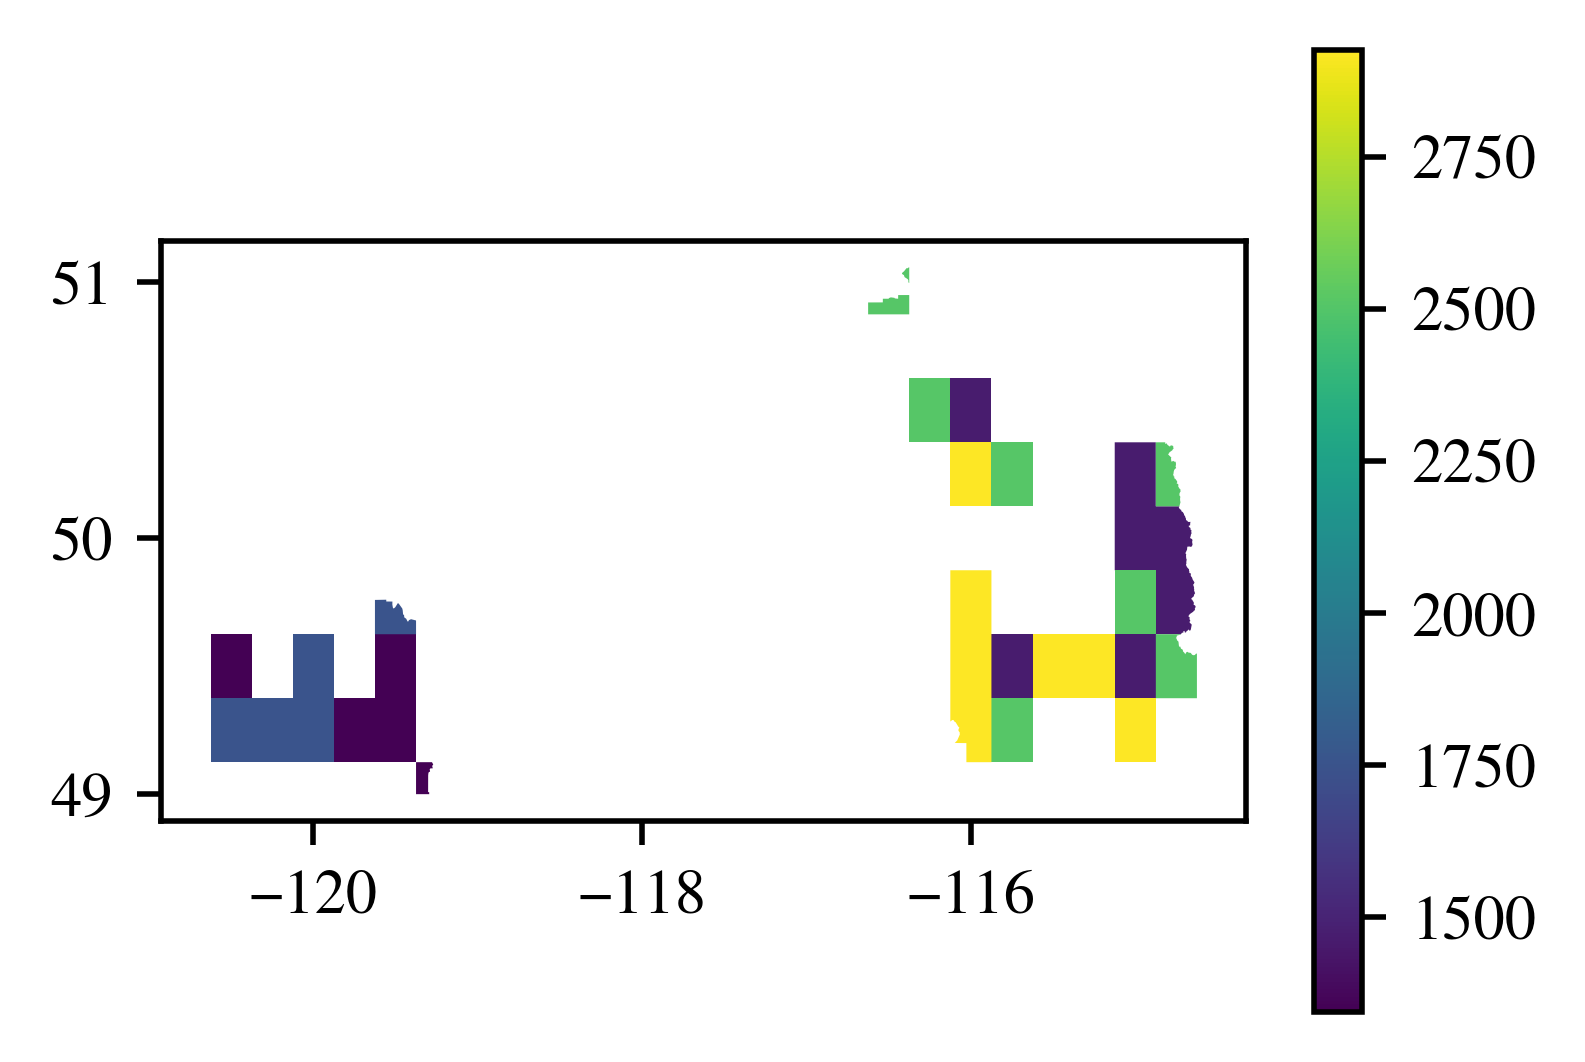

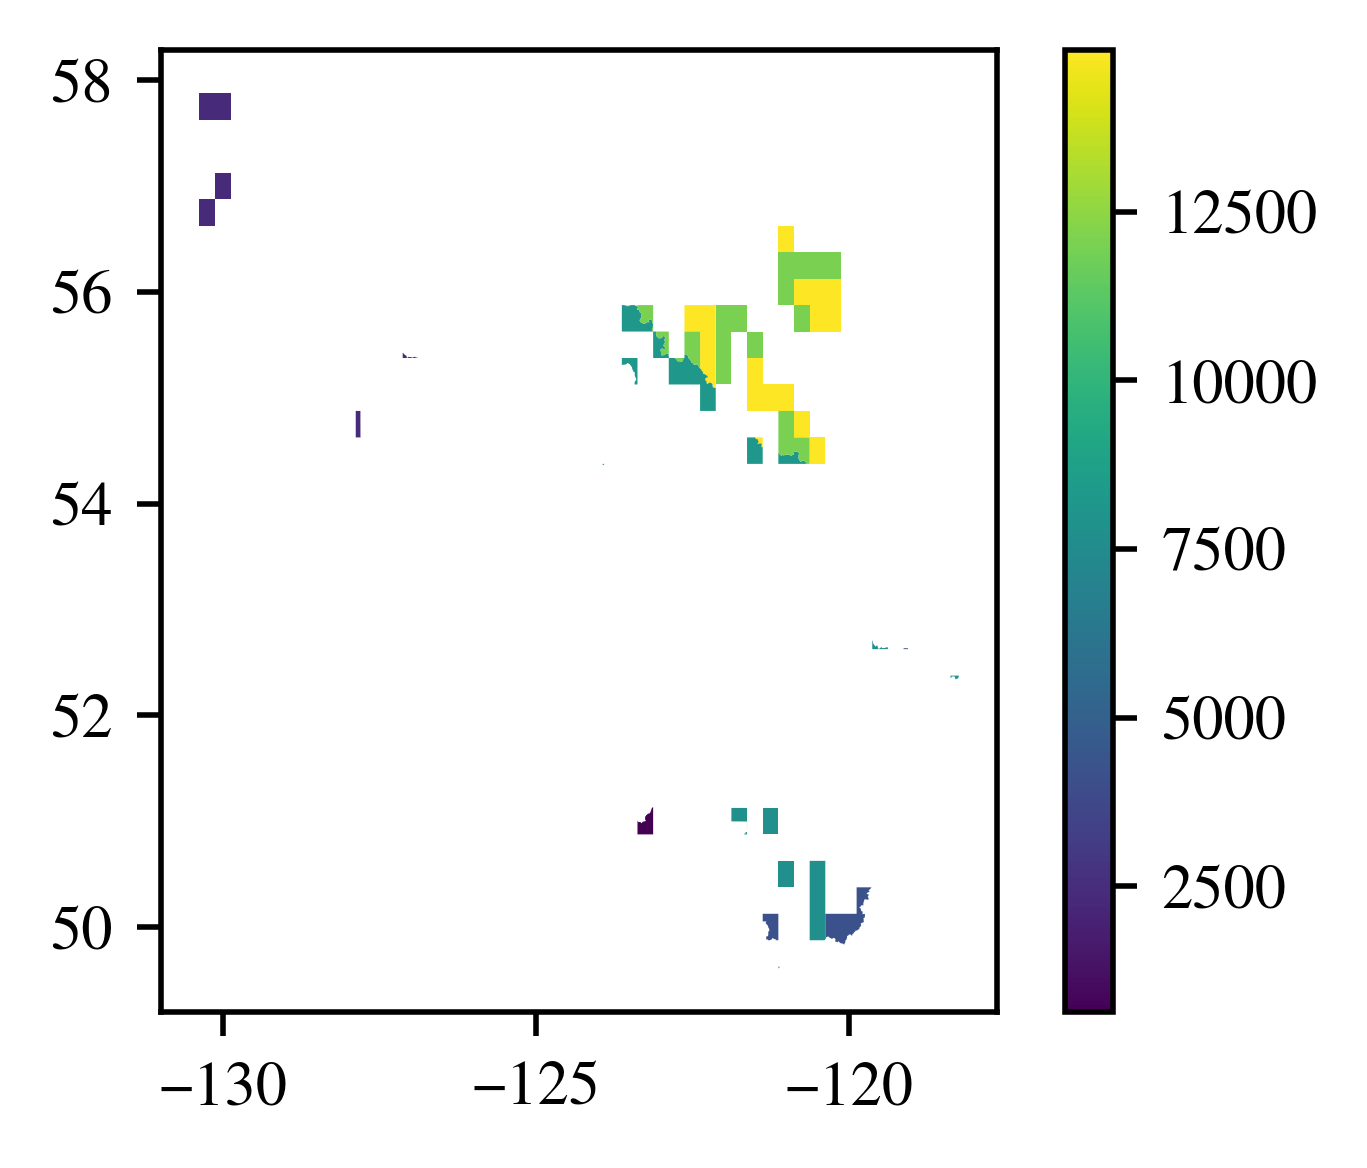

In [54]:
resource_clusters_solar.plot('potential_capacity',legend=True)
resource_clusters_wind.plot('potential_capacity',legend=True)